# Technology Layoffs: Trends and Coverage

Built a reproducible analysis of 2,412 reported technology-layoff records, with monthly, industry and geographic views. Audited missing counts and reported observed totals separately from data coverage instead of filling missing events with invented numbers. Produced reusable tables and visualizations for a data-storytelling article, with clear limits on completeness and causal interpretation.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Validated dates and layoff counts, removed exact duplicates, and produced monthly, annual, industry and country summaries. Missing event counts remain missing; aggregate tables explicitly track coverage. No median or zero imputation is used to invent missing layoffs.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,value
dataset,Local tech_layoffs_til_2025.csv snapshot
input_sha256,a87beb789ce7cda3e1f472131137e35c29e8c4f284c77e...
source_rows,2412
clean_rows,2412
exact_duplicates_removed,0
negative_counts_set_missing,0
missing_layoff_count_rows,372
invalid_or_missing_dates,0
observed_total_layoffs,746809.0
start_date,2020-03-12


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: a87beb789ce7cda3e1f472131137e35c29e8c4f284c77ec64b566845cb576d52


## Figures

industry_layoffs.png


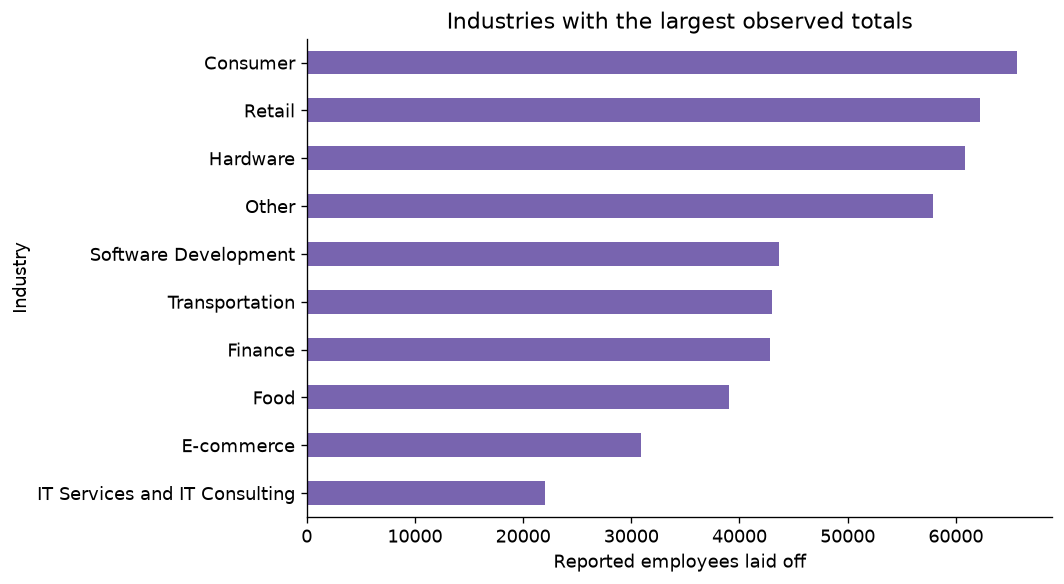

monthly_layoffs.png


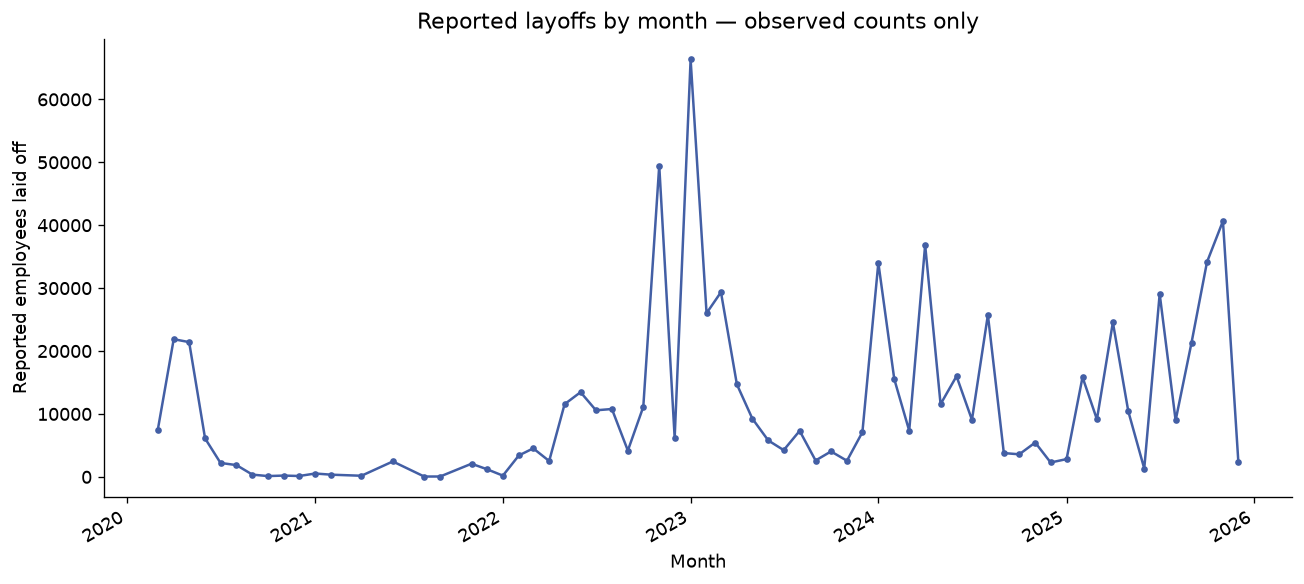

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

The snapshot has 2,412 records from March 2020 to December 2025 and 372 missing layoff counts. Its observed total of 746,809 represents reported counts within this file, not a complete estimate of worldwide layoffs. Temporal and industry differences can reflect reporting coverage; they do not establish causes.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python analyze.py --data data/tech_layoffs_til_2025.csv --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)